In [1]:
from google.colab import files
uploaded = files.upload()

Saving crop_loan_dataset_realistic.xlsx to crop_loan_dataset_realistic.xlsx


Decision Tree

Performing 5-fold Cross-Validation...

Cross-Validated Accuracy: 0.789
Cross-Validated Precision: 0.8269896193771626
Cross-Validated Confusion Matrix:
 [[311 100]
 [111 478]]


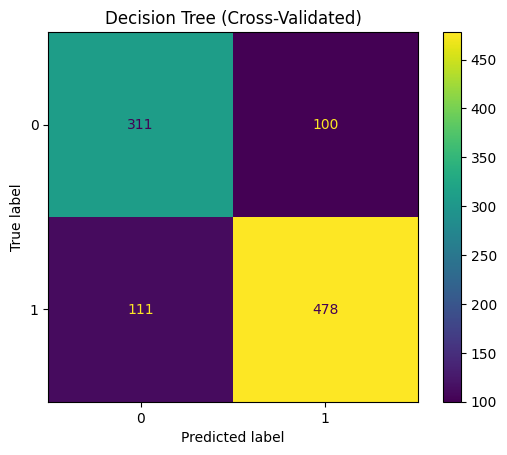

In [2]:
# ============================================================
# Step 1: Import Libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score
import numpy as np


# ============================================================
# Step 2: Load Dataset
# ============================================================


df = pd.read_excel("crop_loan_dataset_realistic.xlsx")

df.head()


# ============================================================
# Step 3: Data Preprocessing
# ============================================================

df = df.drop(columns=["Application_ID"])

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])


# ============================================================
# Step 4: Split Data (for cross-validation, we define X and y)
# ============================================================

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# ============================================================
# Step 5: Initialize Decision Tree Model
# ============================================================

model = DecisionTreeClassifier(random_state=42)

# ============================================================
# Step 6: Cross-Validation
# ============================================================

print("Performing 5-fold Cross-Validation...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Get cross-validated predictions
y_pred_cv = cross_val_predict(model, X, y, cv=kf)

# ============================================================
# Step 7: Cross-Validated Evaluation
# ============================================================

# Cross-validated Accuracy
accuracy_cv = accuracy_score(y, y_pred_cv)
print("\nCross-Validated Accuracy:", accuracy_cv)

# Cross-validated Precision
precision_cv = precision_score(y, y_pred_cv)
print("Cross-Validated Precision:", precision_cv)

# Cross-validated Confusion Matrix
cm_cv = confusion_matrix(y, y_pred_cv)
print("Cross-Validated Confusion Matrix:\n", cm_cv)

ConfusionMatrixDisplay.from_predictions(y, y_pred_cv)
plt.title("Decision Tree (Cross-Validated)")
plt.show()


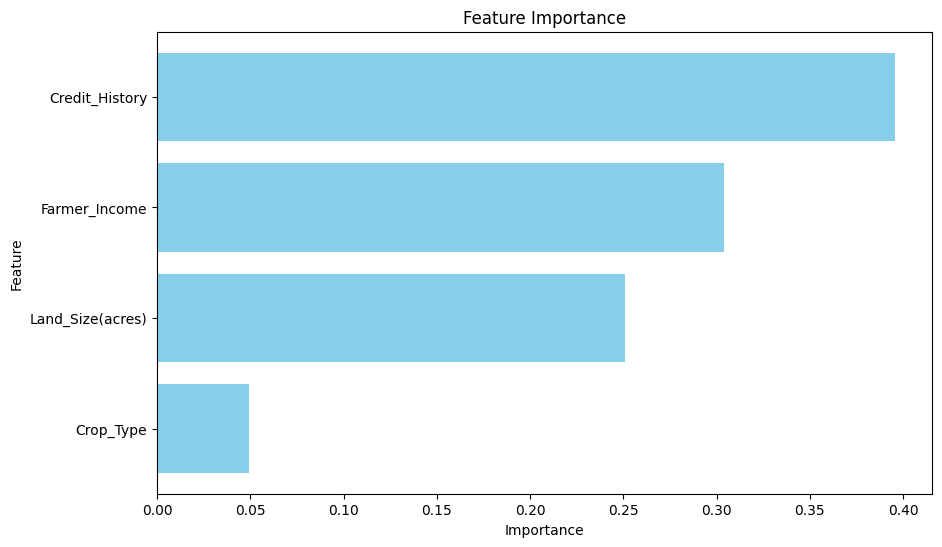

In [3]:
# ============================================================
# Feature Importance Plot
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Fit the model to the entire dataset to get feature importances
model.fit(X, y)

# Get feature importances from the model
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features_df['Feature'], features_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.show()

Logistic Regression


Cross-Validation Accuracy Scores: [0.665 0.755 0.715 0.72  0.715]
Mean CV Accuracy: 0.7140
Standard Deviation of CV Accuracy: 0.0287

Cross-Validated Confusion Matrix:
 [[260 151]
 [135 454]]


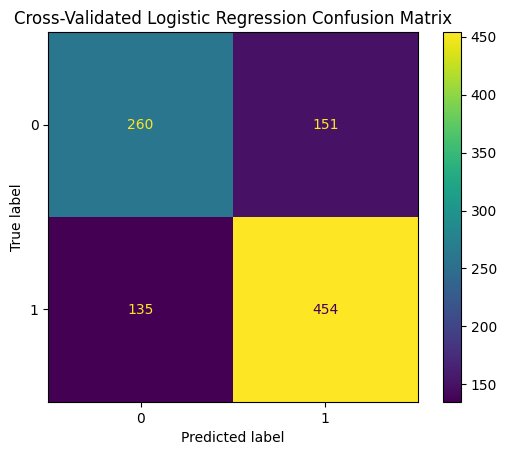

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score


# ============================================================
# Step 2: Load Dataset
# ============================================================



df = pd.read_excel("crop_loan_dataset_realistic.xlsx")

df.head()


# ============================================================
# Step 3: Data Preprocessing
# ============================================================

df = df.drop(columns=["Application_ID"])

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])


# ============================================================
# Step 4: Split Data
# ============================================================

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# ============================================================
# Step 5: Train Logistic Regression Model
# ============================================================

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# ============================================================
# Step 6: Prediction
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# Step 7: Cross-Validation
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("\nCross-Validation Accuracy Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")

# Get cross-validated predictions
y_pred_cv = cross_val_predict(model, X, y, cv=kf)

# Calculate the confusion matrix using the full dataset and CV predictions
cm_cv = confusion_matrix(y, y_pred_cv)
print("\nCross-Validated Confusion Matrix:\n", cm_cv)

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(y, y_pred_cv)
plt.title("Cross-Validated Logistic Regression Confusion Matrix")
plt.show()

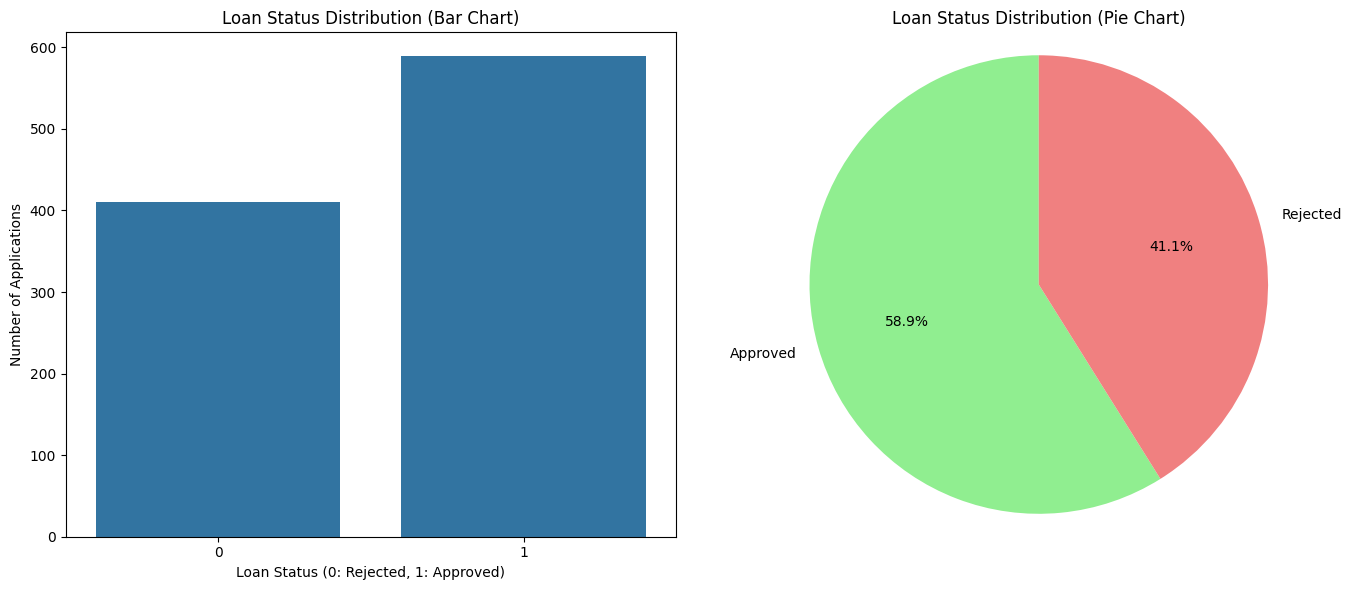

In [5]:
loan_status_counts = df['Loan_Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart
sns.barplot(x=loan_status_counts.index, y=loan_status_counts.values, ax=axes[0])
axes[0].set_title('Loan Status Distribution (Bar Chart)')
axes[0].set_xlabel('Loan Status (0: Rejected, 1: Approved)')
axes[0].set_ylabel('Number of Applications')

# Pie Chart
axes[1].pie(loan_status_counts.values, labels=['Approved', 'Rejected'], autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral'])
axes[1].set_title('Loan Status Distribution (Pie Chart)')
axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()

Crop Type vs. Loan Status


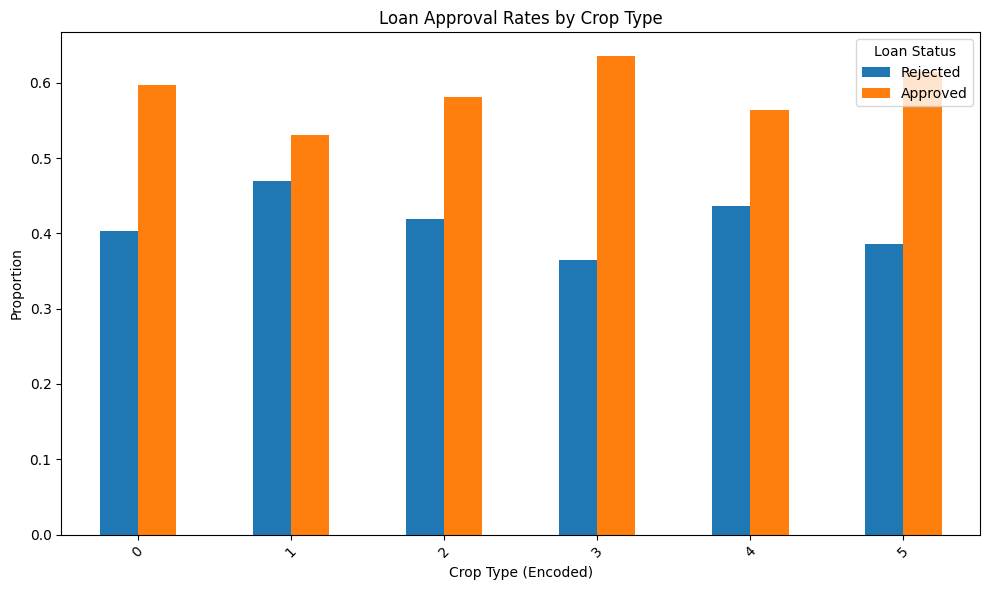

In [6]:
crop_loan = df.groupby(['Crop_Type', 'Loan_Status']).size().unstack(fill_value=0)
crop_loan_percentage = crop_loan.apply(lambda x: x / x.sum(), axis=1)

crop_loan_percentage.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Loan Approval Rates by Crop Type')
plt.xlabel('Crop Type (Encoded)')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
plt.tight_layout()
plt.show()

Credit History vs. Loan Status

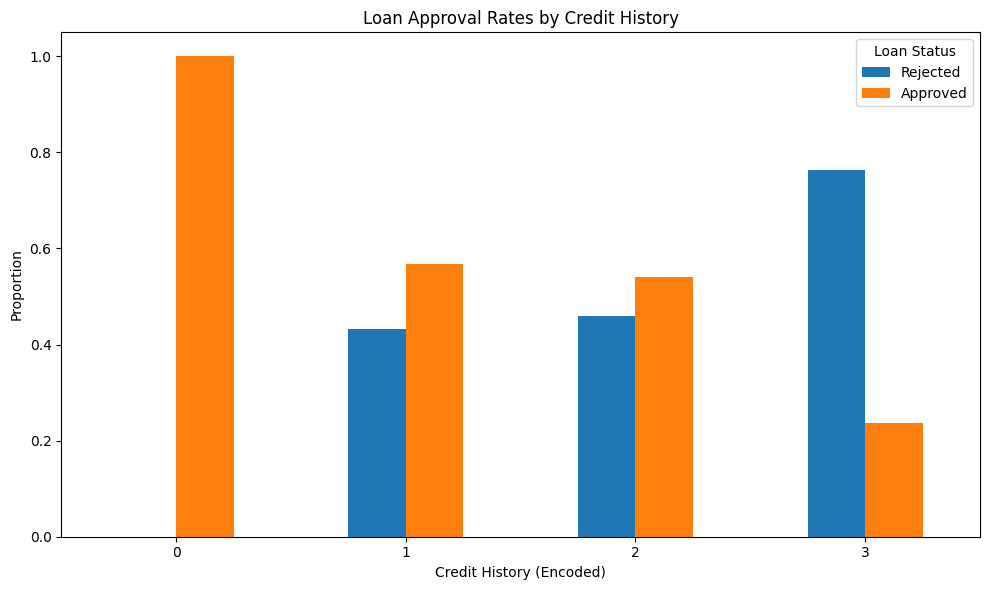

In [7]:
credit_loan = df.groupby(['Credit_History', 'Loan_Status']).size().unstack(fill_value=0)
credit_loan_percentage = credit_loan.apply(lambda x: x / x.sum(), axis=1)

credit_loan_percentage.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Loan Approval Rates by Credit History')
plt.xlabel('Credit History (Encoded)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
plt.tight_layout()
plt.show()

Random Forest


--- Cross-validated Model Evaluation ---
Cross-validation Accuracy Scores: [0.78  0.725 0.785 0.795 0.735]
Mean CV Accuracy: 0.7640
Standard Deviation of CV Accuracy: 0.0284
Cross-validation Precision Scores: [0.78092775 0.72202751 0.79487218 0.79383064 0.73269305]
Mean CV Precision: 0.7649
Standard Deviation of CV Precision: 0.0312

Cross-validated Confusion Matrix:
 [[288 123]
 [113 476]]


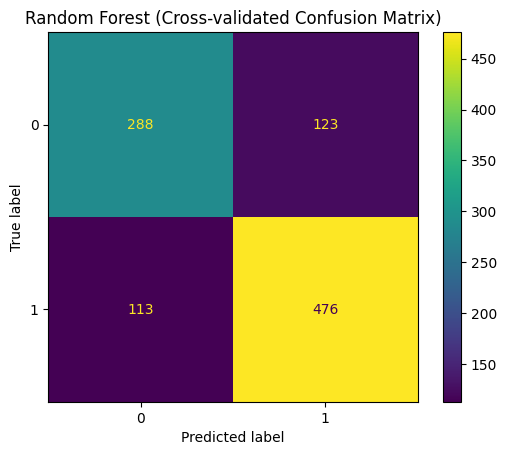

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score


df = pd.read_excel("crop_loan_dataset_realistic.xlsx")

df.head()


# ============================================================
# Step 3: Data Preprocessing
# ============================================================

df = df.drop(columns=["Application_ID"])

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])


# ============================================================
# Step 4: Split Data (for training the initial model)
# ============================================================

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# ============================================================
# Step 5: Train Random Forest Model
# ============================================================

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# ============================================================
# Step 6 & 7: Cross-validated Evaluation
# ============================================================

print("\n--- Cross-validated Model Evaluation ---")

# Define the number of splits for cross-validation
n_splits = 5

# Create a StratifiedKFold object
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Perform cross-validation for accuracy
cv_accuracy_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
print(f"Cross-validation Accuracy Scores: {cv_accuracy_scores}")
print(f"Mean CV Accuracy: {cv_accuracy_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_accuracy_scores.std():.4f}")

# Perform cross-validation for precision (using weighted average for imbalanced classes)
cv_precision_scores = cross_val_score(model, X, y, cv=skf, scoring='precision_weighted')
print(f"Cross-validation Precision Scores: {cv_precision_scores}")
print(f"Mean CV Precision: {cv_precision_scores.mean():.4f}")
print(f"Standard Deviation of CV Precision: {cv_precision_scores.std():.4f}")

# Get cross-validated predictions for confusion matrix (predicts for each sample when it's in the test set)
y_pred_cv = cross_val_predict(model, X, y, cv=skf)

# Compute and display the cross-validated confusion matrix
cm_cv = confusion_matrix(y, y_pred_cv)
print("\nCross-validated Confusion Matrix:\n", cm_cv)

ConfusionMatrixDisplay.from_predictions(y, y_pred_cv)
plt.title("Random Forest (Cross-validated Confusion Matrix)")
plt.show()

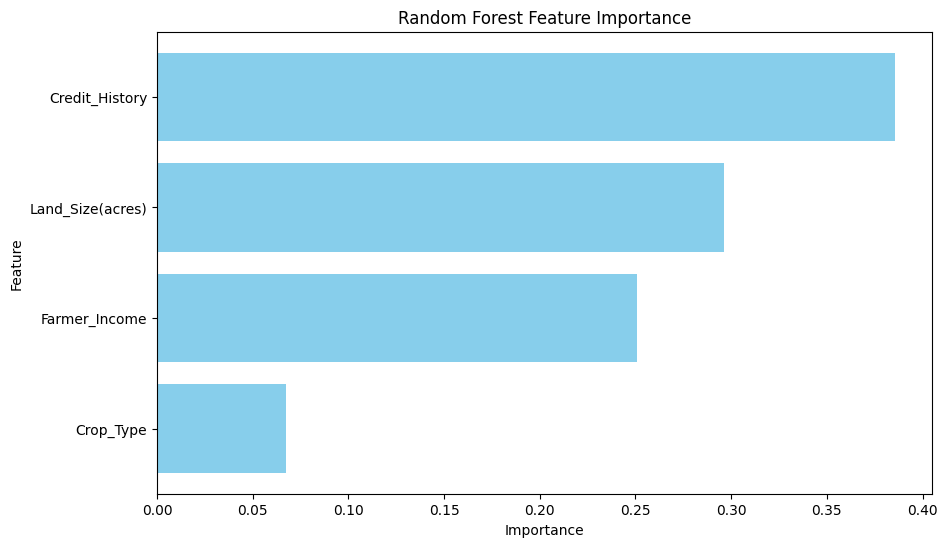

In [9]:
# ============================================================
# Feature Importance Plot
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the model
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features_df['Feature'], features_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.show()